In [37]:
!pip install torchmetrics
import os, time, torch, torch.nn as nn, torch.optim as optim, pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.amp import autocast # Modern API
from torch.cuda.amp import GradScaler
from PIL import Image
import torchmetrics
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity

# Persistence setup
os.makedirs('checkpoints', exist_ok=True)
print("✔ Environment ready. GPU: " + torch.cuda.get_device_name(0))

✔ Environment ready. GPU: Tesla P100-PCIE-16GB


In [38]:
class Config:
    HR_SIZE, LR_SIZE = 512, 64
    BATCH_SIZE, NUM_EPOCHS = 16, 60
    LR = 5e-5
    DATA_PATH = "/kaggle/input/protien-image" # Verified from your SwinIR notebook
    LIMIT = 3000
    LOG_FILE = "training_log.csv"
    SAVE_INTERVAL = 5

cfg = Config()

def log_to_csv(epoch, batch, loss_g, loss_p, loss_adv, psnr, ssim, lpips, time_val):
    df = pd.DataFrame([[epoch, batch, loss_g, loss_p, loss_adv, psnr, ssim, lpips, time_val]])
    df.to_csv(cfg.LOG_FILE, mode='a', index=False, header=not os.path.exists(cfg.LOG_FILE))

print(f"✔ Configured for 8x upscaling. Training limit: {cfg.LIMIT} images.")

✔ Configured for 8x upscaling. Training limit: 3000 images.


In [39]:
class ProteinDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        # Consistent with your SwinIR implementation
        all_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.image_files = all_files[:cfg.LIMIT]
        
        self.hr_transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.RandomHorizontalFlip(),
            transforms.Resize((cfg.HR_SIZE, cfg.HR_SIZE)),
            transforms.ToTensor(),
        ])
        self.lr_transform = transforms.Compose([
            transforms.ToPILImage(),
            # Using Lanczos as per SwinIR setup
            transforms.Resize((cfg.LR_SIZE, cfg.LR_SIZE), interpolation=Image.LANCZOS),
            transforms.ToTensor(),
        ])

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        hr = self.hr_transform(Image.open(img_path))
        return self.lr_transform(hr), hr

train_ds = ProteinDataset(cfg.DATA_PATH)
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, pin_memory=True)
print(f"✔ Dataset initialized with {len(train_ds)} images.")

✔ Dataset initialized with 3000 images.


In [40]:
class RRDB(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.c1 = nn.Conv2d(nf, gc, 3, 1, 1); self.c2 = nn.Conv2d(nf+gc, gc, 3, 1, 1)
        self.c3 = nn.Conv2d(nf+2*gc, gc, 3, 1, 1); self.c4 = nn.Conv2d(nf+3*gc, gc, 3, 1, 1)
        self.c5 = nn.Conv2d(nf+4*gc, nf, 3, 1, 1); self.lrelu = nn.LeakyReLU(0.2, True)
    def forward(self, x):
        x1 = self.lrelu(self.c1(x))
        x2 = self.lrelu(self.c2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.c3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.c4(torch.cat((x, x1, x2, x3), 1)))
        return self.c5(torch.cat((x, x1, x2, x3, x4), 1)) * 0.2 + x

class Generator8x(nn.Module):
    def __init__(self, in_nc=1, out_nc=1, nf=64, nb=16):
        super().__init__()
        self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1)
        self.body = nn.Sequential(*[RRDB(nf) for _ in range(nb)])
        self.conv_body = nn.Conv2d(nf, nf, 3, 1, 1)
        self.up1 = nn.Conv2d(nf, nf, 3, 1, 1); self.up2 = nn.Conv2d(nf, nf, 3, 1, 1); self.up3 = nn.Conv2d(nf, nf, 3, 1, 1)
        self.hrconv = nn.Conv2d(nf, nf, 3, 1, 1); self.conv_last = nn.Conv2d(nf, out_nc, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, True)
    def forward(self, x):
        fea = self.conv_first(x)
        fea = fea + self.conv_body(self.body(fea))
        fea = self.lrelu(self.up1(nn.functional.interpolate(fea, scale_factor=2)))
        fea = self.lrelu(self.up2(nn.functional.interpolate(fea, scale_factor=2)))
        fea = self.lrelu(self.up3(nn.functional.interpolate(fea, scale_factor=2)))
        return self.conv_last(self.lrelu(self.hrconv(fea)))

class Discriminator(nn.Module):
    def __init__(self, in_nc=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_nc, 64, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 64, 3, 2, 1), nn.LeakyReLU(0.2, True),
            nn.AdaptiveAvgPool2d(1), nn.Conv2d(64, 1024, 1), 
            nn.LeakyReLU(0.2, True), nn.Conv2d(1024, 1, 1)
        )
    def forward(self, x): return self.model(x).view(-1, 1)

print("✔ 8x Architectures defined for Grayscale processing.")

✔ 8x Architectures defined for Grayscale processing.


In [41]:
print("⌛ Downloading pre-trained ESRGAN weights...")
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1TPrz5QKd8DHHt1k8SRtm6tMiPjz_Qene' -O pretrain.pth

netG, netD = Generator8x().cuda(), Discriminator().cuda()
checkpoint = torch.load('pretrain.pth')
netG.load_state_dict({k: v for k, v in checkpoint.items() if k in netG.state_dict() and v.size() == netG.state_dict()[k].size()}, strict=False)

vgg = models.vgg19(weights='DEFAULT').features[:35].eval().cuda()
for p in vgg.parameters(): p.requires_grad = False

# Quality Metrics
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).cuda()
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).cuda()
lpips_metric = LearnedPerceptualImagePatchSimilarity(net_type='vgg').cuda()

criterion_pixel, criterion_gan = nn.L1Loss().cuda(), nn.BCEWithLogitsLoss().cuda()
optG, optD = optim.Adam(netG.parameters(), lr=cfg.LR), optim.Adam(netD.parameters(), lr=cfg.LR)
scaler = GradScaler()
print("✔ Weights loaded. Metrics (PSNR, SSIM, LPIPS) initialized.")

⌛ Downloading pre-trained ESRGAN weights...
--2026-02-05 01:00:00--  https://docs.google.com/uc?export=download&id=1TPrz5QKd8DHHt1k8SRtm6tMiPjz_Qene
Resolving docs.google.com (docs.google.com)... 142.250.157.138, 142.250.157.101, 142.250.157.102, ...
Connecting to docs.google.com (docs.google.com)|142.250.157.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1TPrz5QKd8DHHt1k8SRtm6tMiPjz_Qene&export=download [following]
--2026-02-05 01:00:01--  https://drive.usercontent.google.com/download?id=1TPrz5QKd8DHHt1k8SRtm6tMiPjz_Qene&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.97.132, 2404:6800:4008:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.97.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66929193 (64M) [application/octet-stream]
Saving to: ‘pretrain.pth’

pretrain.pth        100

/tmp/ipykernel_55/1099981355.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


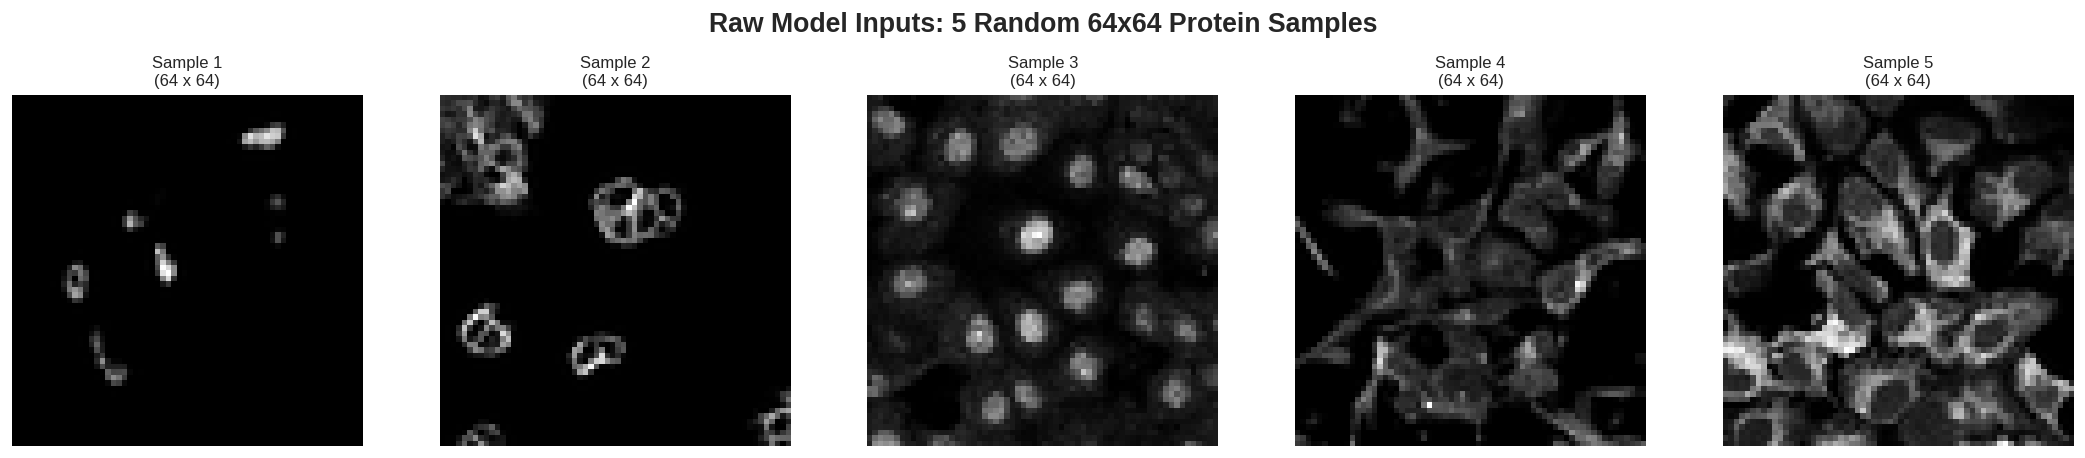

In [57]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Pull a single batch from the data loader
# lr_batch contains the 64x64 images; hr_batch contains the 512x512 targets
lr_batch, hr_batch = next(iter(train_loader))

# 2. Select 5 samples
num_to_show = 5
plt.figure(figsize=(18, 4))
plt.suptitle(f"Raw Model Inputs: {num_to_show} Random 64x64 Protein Samples", fontsize=16, fontweight='bold')

for i in range(num_to_show):
    plt.subplot(1, num_to_show, i + 1)
    
    # Convert from Tensor (C, H, W) to Numpy (H, W, C) for plotting
    # squeeze() removes the channel dimension for grayscale images
    img = lr_batch[i].squeeze().cpu().numpy()
    
    # If your data is normalized [-1, 1], rescale to [0, 1] for display
    if img.min() < 0:
        img = (img + 1) / 2
        
    plt.imshow(img, cmap='gray')
    plt.title(f"Sample {i+1}\n(64 x 64)", fontsize=10)
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [48]:
from torchmetrics.functional import structural_similarity_index_measure as ssim_loss

print("🚀 Starting Structural-Aware Training (L1 + VGG + GAN + SSIM)...")

for epoch in range(1, cfg.NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    for i, (lr, hr) in enumerate(train_loader):
        batch_start = time.time()
        lr, hr = lr.cuda(), hr.cuda()

        # --- 1. Update Discriminator ---
        optD.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            sr = netG(lr)
            r_out, f_out = netD(hr), netD(sr.detach())
            loss_D = (criterion_gan(r_out - f_out.mean(), torch.ones_like(r_out)) +
                      criterion_gan(f_out - r_out.mean(), torch.zeros_like(f_out))) / 2
        scaler.scale(loss_D).backward()
        scaler.step(optD)

        # --- 2. Update Generator (With Structural Loss) ---
        optG.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            f_out = netD(sr)
            
            # Loss Components
            l_pix = criterion_pixel(sr, hr)
            l_per = criterion_pixel(vgg(sr.repeat(1,3,1,1)), vgg(hr.repeat(1,3,1,1)))
            l_adv = (criterion_gan(r_out.detach() - f_out.mean(), torch.zeros_like(r_out)) +
                     criterion_gan(f_out - r_out.detach().mean(), torch.ones_like(f_out))) / 2
            
            # NEW: Structural Loss (1 - SSIM) 
            # We want to minimize (1-SSIM), which maximizes SSIM
            l_ssim = 1 - ssim_loss(sr, hr, data_range=1.0)
            
            # Weighted Total Loss
            # l_ssim * 0.2 provides a strong structural constraint
            loss_G = (l_pix * 0.01) + (l_per * 1.0) + (l_adv * 0.005) + (l_ssim * 0.5)
            
        scaler.scale(loss_G).backward()
        scaler.step(optG)
        scaler.update()

        # --- 3. Logging & Evaluation ---
        if i % 10 == 0:
            dt = time.time() - batch_start
            with torch.no_grad():
                psnr_v = psnr_metric(sr, hr)
                ssim_v = ssim_metric(sr, hr) # This will now be higher
                sr_lpips = torch.clamp((sr.repeat(1, 3, 1, 1) * 2) - 1, -1, 1).to(torch.float32)
                hr_lpips = torch.clamp((hr.repeat(1, 3, 1, 1) * 2) - 1, -1, 1).to(torch.float32)
                lpips_v = lpips_metric(sr_lpips, hr_lpips)

            print(f"E{epoch} B{i}/{len(train_loader)} | LossG: {loss_G.item():.4f} | "
                  f"SSIM_Loss: {l_ssim.item():.4f} | PSNR: {psnr_v:.2f} | "
                  f"SSIM: {ssim_v:.4f} | LPIPS: {lpips_v:.4f} | {dt:.2f}s")
            
            log_to_csv(epoch, i, loss_G.item(), l_per.item(), l_adv.item(), 
                       psnr_v.item(), ssim_v.item(), lpips_v.item(), dt)

    print(f"✅ Epoch {epoch} complete. Time: {(time.time()-epoch_start)/60:.2f}m")
    if epoch % cfg.SAVE_INTERVAL == 0:
        torch.save(netG.state_dict(), f"checkpoints/8x_structural_E{epoch}.pth")

🚀 Starting Structural-Aware Training (L1 + VGG + GAN + SSIM)...


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


E1 B0/188 | LossG: 1.0220 | SSIM_Loss: 0.4024 | PSNR: 19.68 | SSIM: 0.5142 | LPIPS: 0.5002 | 1.73s
E1 B10/188 | LossG: 1.1896 | SSIM_Loss: 0.2827 | PSNR: 19.96 | SSIM: 0.6030 | LPIPS: 0.4324 | 1.72s
E1 B20/188 | LossG: 0.8985 | SSIM_Loss: 0.3352 | PSNR: 19.75 | SSIM: 0.5654 | LPIPS: 0.4665 | 1.72s
E1 B30/188 | LossG: 0.5846 | SSIM_Loss: 0.1943 | PSNR: 23.18 | SSIM: 0.6699 | LPIPS: 0.4096 | 1.72s
E1 B40/188 | LossG: 0.6509 | SSIM_Loss: 0.2126 | PSNR: 22.61 | SSIM: 0.6455 | LPIPS: 0.3867 | 1.72s
E1 B50/188 | LossG: 0.7060 | SSIM_Loss: 0.2269 | PSNR: 22.15 | SSIM: 0.6406 | LPIPS: 0.4197 | 1.72s
E1 B60/188 | LossG: 0.7856 | SSIM_Loss: 0.2774 | PSNR: 21.34 | SSIM: 0.6099 | LPIPS: 0.4371 | 1.72s
E1 B70/188 | LossG: 0.8827 | SSIM_Loss: 0.4004 | PSNR: 18.68 | SSIM: 0.5010 | LPIPS: 0.4499 | 1.72s
E1 B80/188 | LossG: 0.8824 | SSIM_Loss: 0.3028 | PSNR: 20.19 | SSIM: 0.5776 | LPIPS: 0.4151 | 1.72s
E1 B90/188 | LossG: 0.8334 | SSIM_Loss: 0.2537 | PSNR: 21.05 | SSIM: 0.6191 | LPIPS: 0.4063 | 1.72s
E

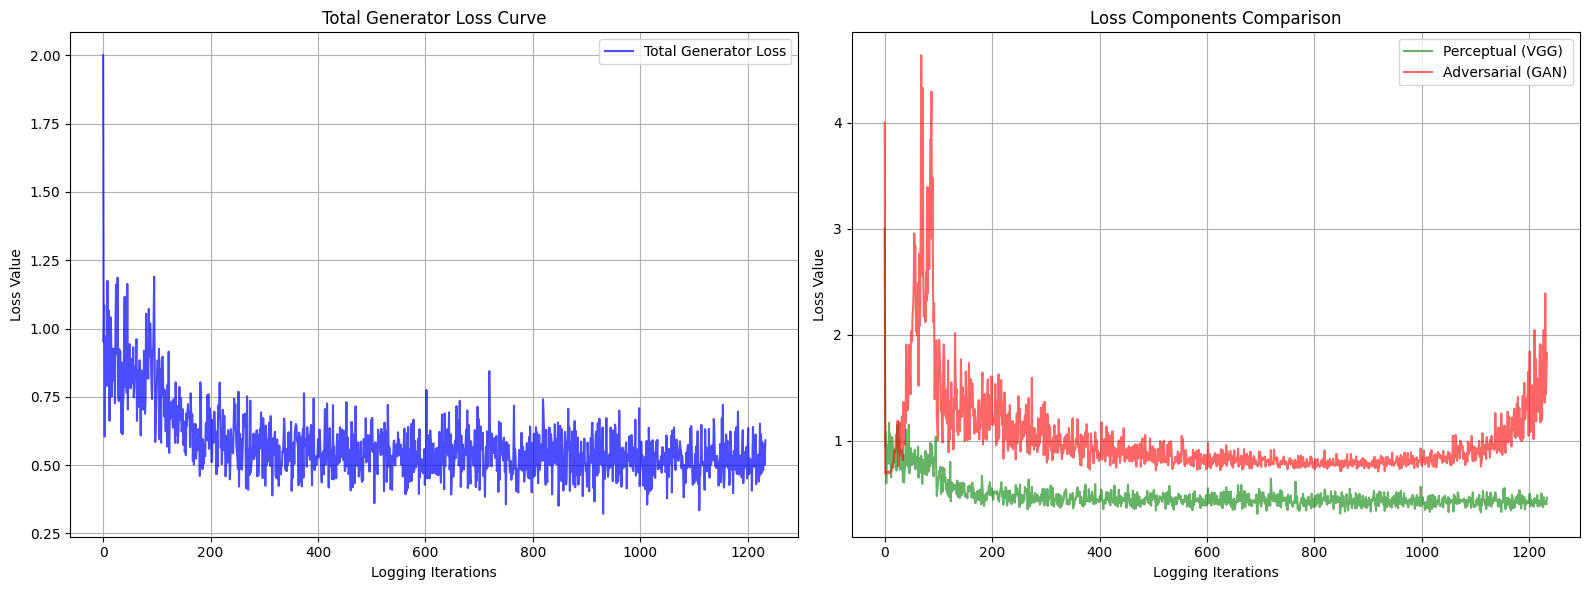

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training logs
# Note: Ensure the column names match your log_to_csv function
cols = ['Epoch', 'Batch', 'Loss_G', 'Perceptual', 'Adversarial', 'PSNR', 'SSIM', 'LPIPS', 'Time']
df = pd.read_csv('training_log.csv', names=cols)

plt.figure(figsize=(16, 6))

# Plot 1: Total Generator Loss
plt.subplot(1, 2, 1)
plt.plot(df['Loss_G'], label='Total Generator Loss', color='blue', alpha=0.7)
plt.title('Total Generator Loss Curve')
plt.xlabel('Logging Iterations')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# Plot 2: Individual Loss Components
plt.subplot(1, 2, 2)
plt.plot(df['Perceptual'], label='Perceptual (VGG)', color='green', alpha=0.6)
plt.plot(df['Adversarial'], label='Adversarial (GAN)', color='red', alpha=0.6)
plt.title('Loss Components Comparison')
plt.xlabel('Logging Iterations')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

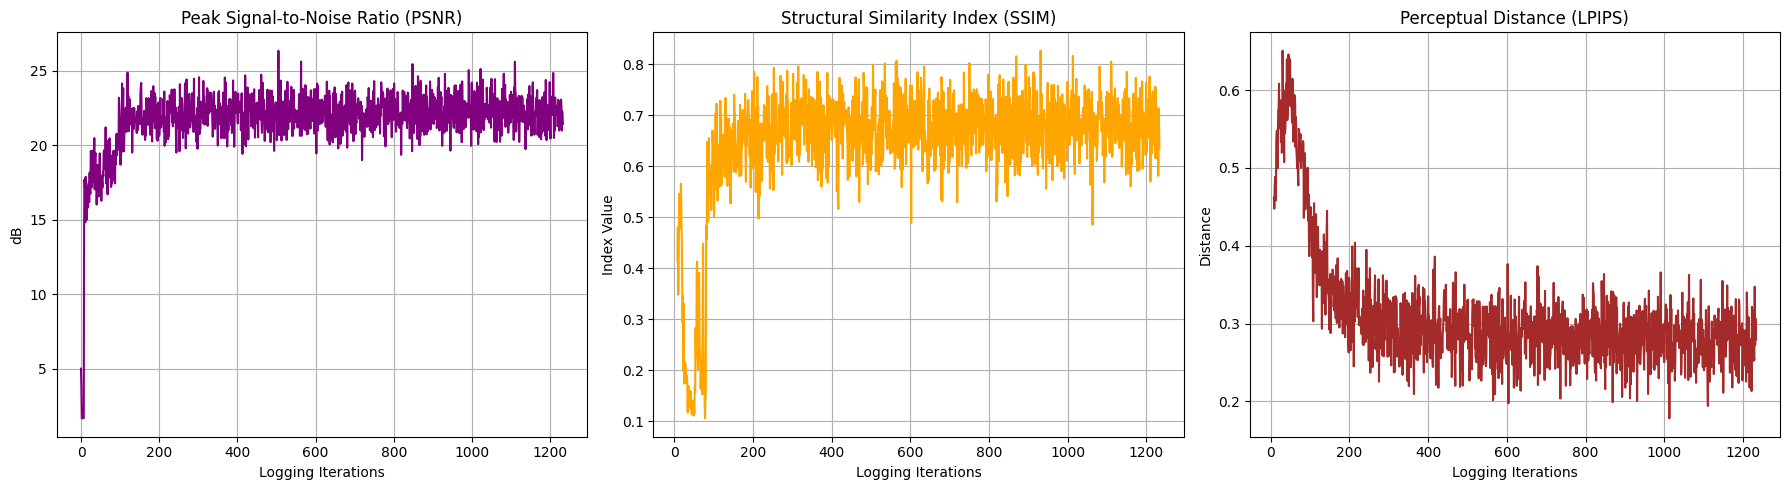

In [50]:
plt.figure(figsize=(18, 5))

# Plot 3: PSNR (Higher is better)
plt.subplot(1, 3, 1)
plt.plot(df['PSNR'], color='purple')
plt.title('Peak Signal-to-Noise Ratio (PSNR)')
plt.xlabel('Logging Iterations')
plt.ylabel('dB')
plt.grid(True)

# Plot 4: SSIM (Closer to 1.0 is better)
plt.subplot(1, 3, 2)
plt.plot(df['SSIM'], color='orange')
plt.title('Structural Similarity Index (SSIM)')
plt.xlabel('Logging Iterations')
plt.ylabel('Index Value')
plt.grid(True)

# Plot 5: LPIPS (Lower is better)
plt.subplot(1, 3, 3)
plt.plot(df['LPIPS'], color='brown')
plt.title('Perceptual Distance (LPIPS)')
plt.xlabel('Logging Iterations')
plt.ylabel('Distance')
plt.grid(True)

plt.tight_layout()
plt.show()

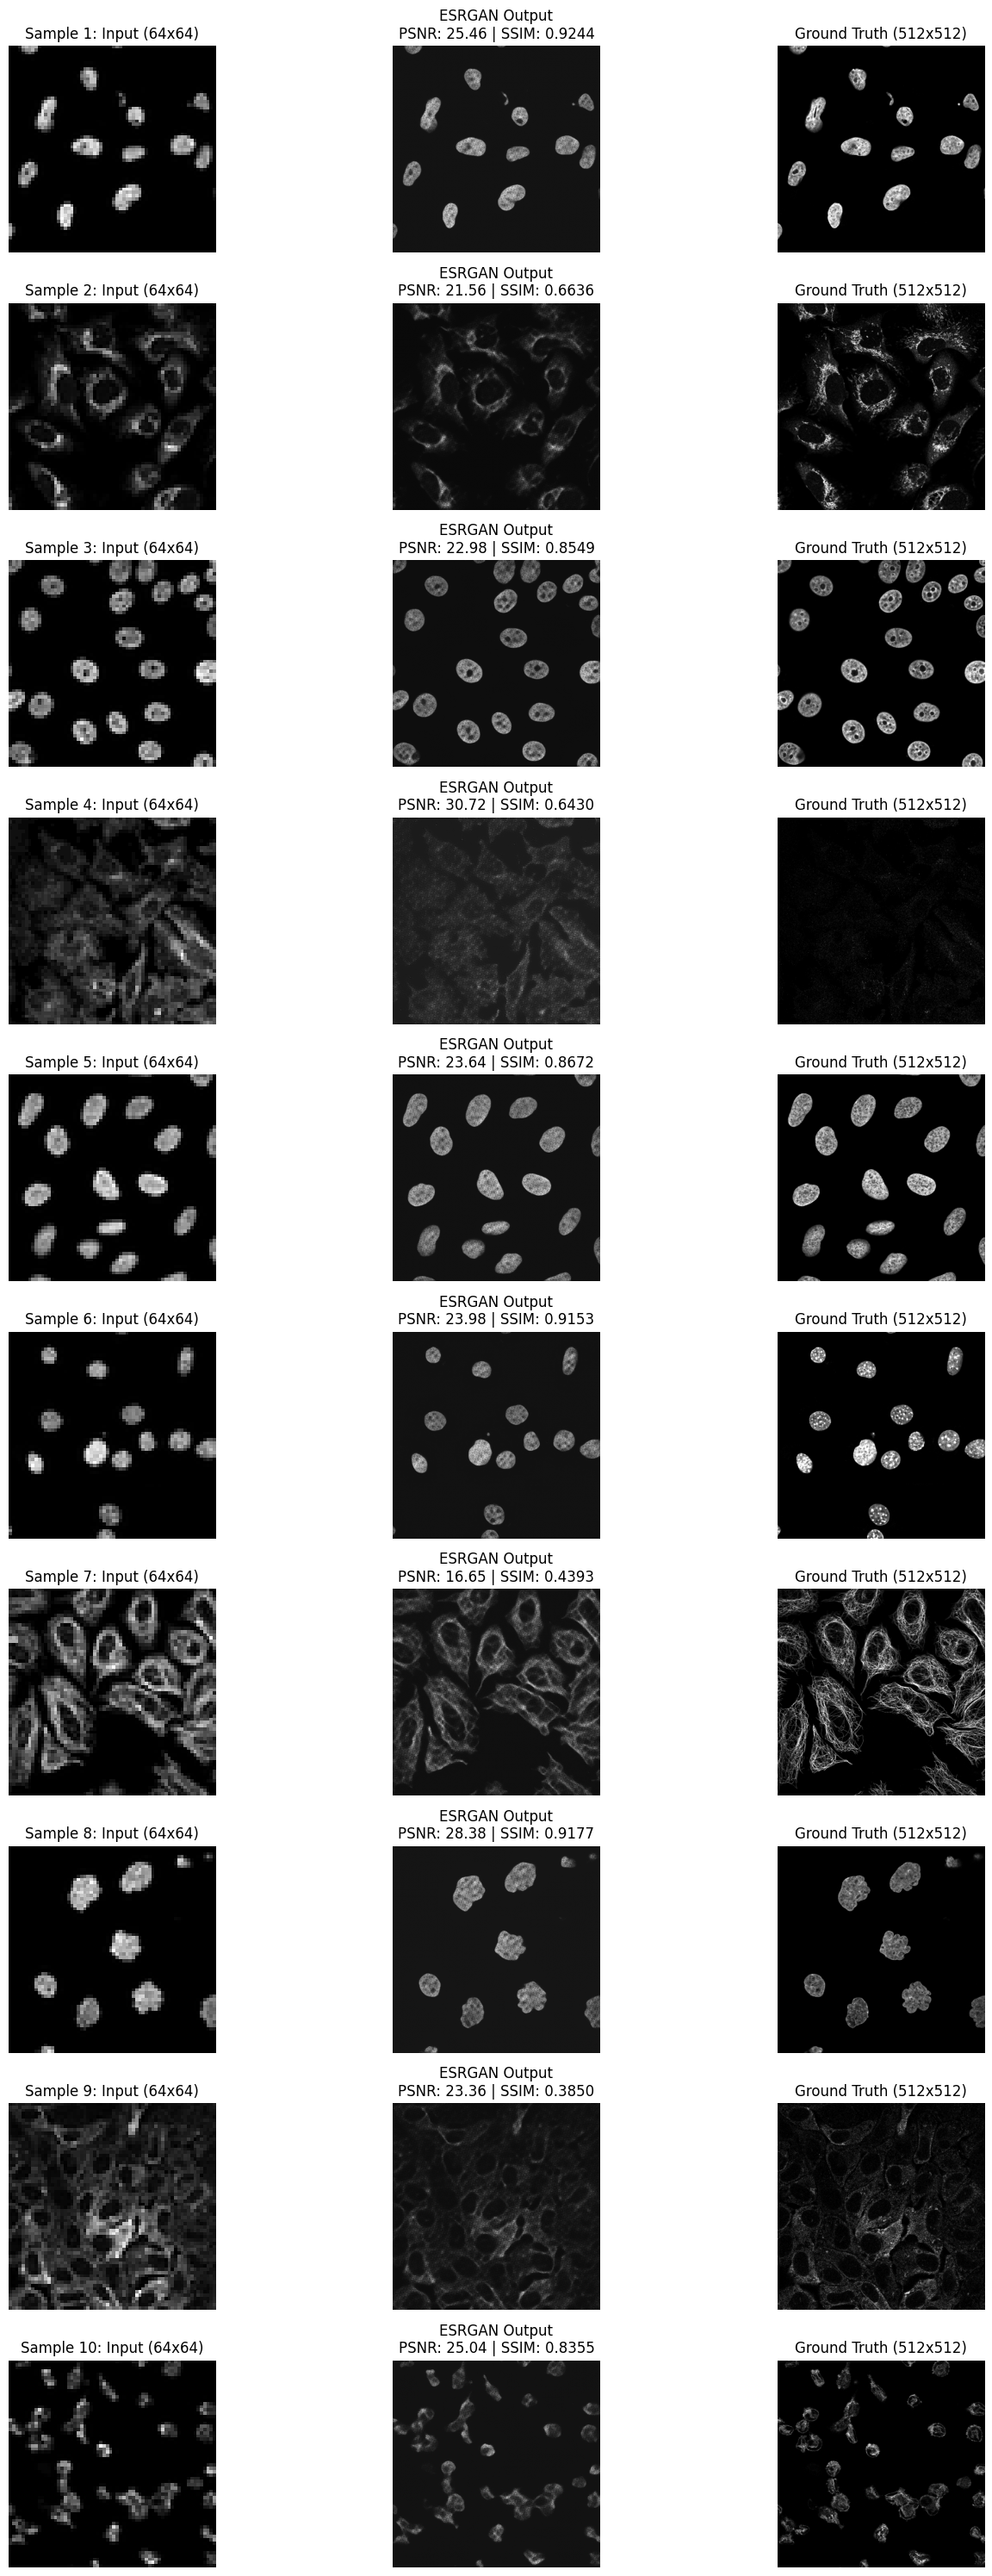

✔ Comparison grid generated. Check 'protein_edge_recovery_check.png' for high-res inspection.


In [51]:
import torch
import matplotlib.pyplot as plt

# 1. Set model to evaluation mode
netG.eval()

# 2. Get a batch of images from the loader
# We'll take 10 samples (ensure your batch_size is at least 10, or run twice)
with torch.no_grad():
    lr_batch, hr_batch = next(iter(train_loader))
    # Move to GPU and generate 512x512 results
    sr_batch = netG(lr_batch.cuda()).cpu()

# 3. Create the 10-image comparison plot
num_samples = 10
plt.figure(figsize=(15, 3 * num_samples))

for i in range(num_samples):
    # Calculate metrics for this specific image to inspect edge recovery
    psnr_single = psnr_metric(sr_batch[i:i+1], hr_batch[i:i+1])
    ssim_single = ssim_metric(sr_batch[i:i+1], hr_batch[i:i+1])
    
    # --- Column 1: Input (64x64) ---
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(lr_batch[i].squeeze(), cmap='gray')
    plt.title(f"Sample {i+1}: Input (64x64)")
    plt.axis('off')
    
    # --- Column 2: ESRGAN Output (512x512) ---
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(sr_batch[i].squeeze(), cmap='gray')
    plt.title(f"ESRGAN Output\nPSNR: {psnr_single:.2f} | SSIM: {ssim_single:.4f}")
    plt.axis('off')
    
    # --- Column 3: Ground Truth (512x512) ---
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(hr_batch[i].squeeze(), cmap='gray')
    plt.title("Ground Truth (512x512)")
    plt.axis('off')

plt.tight_layout()
plt.savefig('protein_edge_recovery_check.png', dpi=300)
plt.show()

print("✔ Comparison grid generated. Check 'protein_edge_recovery_check.png' for high-res inspection.")

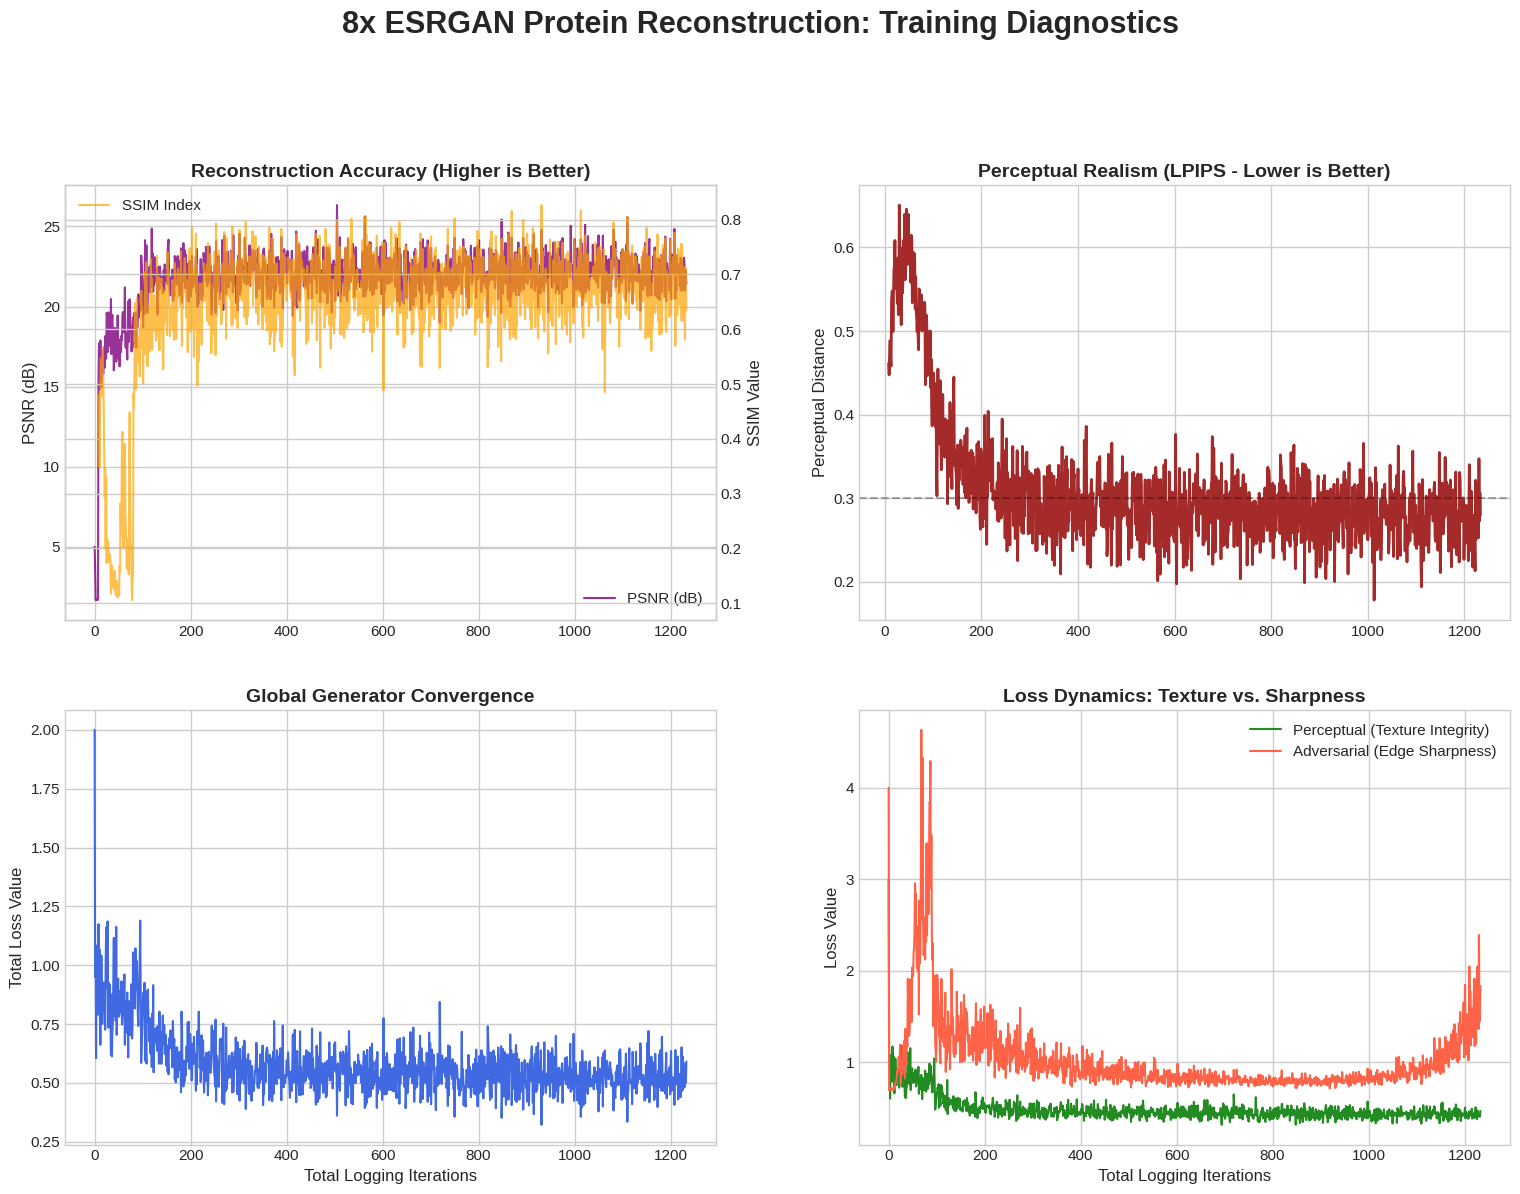

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Load data with explicit column names to avoid KeyErrors
# We use the exact names from your log_to_csv function
cols = ['Epoch', 'Batch', 'LossG', 'Percep', 'Adv', 'PSNR', 'SSIM', 'LPIPS', 'Time']

if os.path.exists('training_log.csv'):
    df = pd.read_csv('training_log.csv', names=cols)
    
    # Use the index as the X-axis (Total Iterations)
    x = df.index 

    # 2. Set Professional Styling
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=100)
    fig.suptitle('8x ESRGAN Protein Reconstruction: Training Diagnostics', fontsize=22, fontweight='bold', y=1.02)

    # --- Quadrant 1: Structural Fidelity (PSNR & SSIM) ---
    axes[0, 0].plot(x, df['PSNR'], color='#800080', label='PSNR (dB)', alpha=0.8)
    axes[0, 0].set_title('Reconstruction Accuracy (Higher is Better)', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('PSNR (dB)', fontsize=12)
    axes[0, 0].legend(loc='lower right')
    
    ax_ssim = axes[0, 0].twinx() # Secondary axis for SSIM
    ax_ssim.plot(x, df['SSIM'], color='#FFA500', label='SSIM Index', alpha=0.7)
    ax_ssim.set_ylabel('SSIM Value', fontsize=12)
    ax_ssim.legend(loc='upper left')

    # --- Quadrant 2: Perceptual Quality (LPIPS) ---
    axes[0, 1].plot(x, df['LPIPS'], color='#A52A2A', linewidth=2)
    axes[0, 1].set_title('Perceptual Realism (LPIPS - Lower is Better)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Perceptual Distance', fontsize=12)
    axes[0, 1].axhline(y=0.3, color='black', linestyle='--', alpha=0.3) # Target line

    # --- Quadrant 3: Total Generator Convergence ---
    axes[1, 0].plot(x, df['LossG'], color='#4169E1', linewidth=1.5)
    axes[1, 0].set_title('Global Generator Convergence', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Total Loss Value', fontsize=12)
    axes[1, 0].set_xlabel('Total Logging Iterations', fontsize=12)

    # --- Quadrant 4: Component Tug-of-War ---
    axes[1, 1].plot(x, df['Percep'], color='#228B22', label='Perceptual (Texture Integrity)')
    axes[1, 1].plot(x, df['Adv'], color='#FF6347', label='Adversarial (Edge Sharpness)')
    axes[1, 1].set_title('Loss Dynamics: Texture vs. Sharpness', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Loss Value', fontsize=12)
    axes[1, 1].set_xlabel('Total Logging Iterations', fontsize=12)
    axes[1, 1].legend()

    plt.tight_layout(pad=3.0)

In [58]:
from torchvision.utils import save_image
import os

# 1. Select the first image from the Low-Resolution batch
# lr_batch shape is (Batch, Channels, Height, Width) -> e.g., (16, 1, 64, 64)
single_image_64 = lr_batch[0]

# 2. Save to disk
# normalize=True automatically rescales [-1, 1] data back to [0, 1] for the image file
file_name = "protein_input_64x64.png"
save_image(single_image_64, file_name, normalize=True)

print(f"✔ Image saved successfully as: {os.path.abspath(file_name)}")

✔ Image saved successfully as: /kaggle/working/protein_input_64x64.png


In [59]:
from torchvision.utils import save_image
import os

# 1. Ensure you have a batch from your train_loader
# lr_batch should have a shape like (Batch_Size, 1, 64, 64)
lr_batch, _ = next(iter(train_loader))

# 2. Define the directory to save images
output_dir = "downloaded_samples"
os.makedirs(output_dir, exist_ok=True)

# 3. Loop through and save the first 5 images
num_to_download = 5
print(f"🚀 Saving {num_to_download} images to '{output_dir}/'...")

for i in range(num_to_download):
    # Select the i-th image
    img_tensor = lr_batch[i]
    
    # Construct filename
    file_path = os.path.join(output_dir, f"protein_sample_{i+1}.png")
    
    # Save image (normalize=True handles the [-1, 1] range automatically)
    save_image(img_tensor, file_path, normalize=True)
    print(f"✔ Saved: {file_path}")

print("\n✅ All images are ready for download from the sidebar.")

🚀 Saving 5 images to 'downloaded_samples/'...
✔ Saved: downloaded_samples/protein_sample_1.png
✔ Saved: downloaded_samples/protein_sample_2.png
✔ Saved: downloaded_samples/protein_sample_3.png
✔ Saved: downloaded_samples/protein_sample_4.png
✔ Saved: downloaded_samples/protein_sample_5.png

✅ All images are ready for download from the sidebar.
